In [1]:
from datascience import *
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
plots.rcParams["patch.force_edgecolor"] = True

### Last Class's Survey

As always, Python reference sheet: https://data8.org/fa26/reference/

In [27]:
survey = Table.read_table('class_survey.csv')
survey

Are you a Barnard student or Columbia student?,What is your major?,Are you left-handed or right-handed?,Roughly how many hours of sleep do you get on a weeknight during the semester?,Roughly how many hours of sleep do you get on a weekend during the semester?,"On any given day, roughly how many browser tabs do you have open?",Did you answer honestly to all of the questions?
Barnard,Economics or Economics-Statistics,Right-handed,7.5,9,20,Yes
Barnard,Cognitive Science,Right-handed,7.5,8,10,Yes
Barnard,Economics or Economics-Statistics,Left-handed,7,8,47,No
Barnard,Economics or Economics-Statistics,Left-handed,7,8,15,Yes
Barnard,Cognitive Science,Right-handed,8,9,10,Yes
Barnard,Cognitive Science,Right-handed,7,6,8,Yes
Barnard,Undeclared,Right-handed,7,9,15,Yes
Barnard,Dance,Ambidextrous,7,11,999,No
Barnard,Economics or Economics-Statistics,Right-handed,8,8,30,Yes
Barnard,Economics or Economics-Statistics,Ambidextrous,8,10,12,Yes


1. How many respondents said they did NOT answer honestly?
2. How many undeclared are right-handed?
3. Which is the best visualization for hours of sleep and browser tabs open?
4. Do we think people were honest about whether they were honest? Hint: We have 2 econ majors. How many people said they lied and how many people said they were an econ major?

In [20]:
survey.labels

('Are you a Barnard student or Columbia student?',
 'What is your major?',
 'Are you left-handed or right-handed?',
 'Roughly how many hours of sleep do you get on a weeknight during the semester?',
 'Roughly how many hours of sleep do you get on a weekend during the semester?',
 'On any given day, roughly how many browser tabs do you have open?',
 'Did you answer honestly to all of the questions?')

In [31]:
survey.group('What is your major?')

What is your major?,count
Applied Mathematics,3
Cognitive Science,6
Dance,3
Economics or Economics-Statistics,15
Psychology,1
Undeclared,7


In [23]:
col_label = 'Did you answer honestly to all of the questions?'

In [24]:
survey.group(col_label)

Did you answer honestly to all of the questions?,count
No,6
Yes,29


In [30]:
survey.where('What is your major?', are.equal_to('Undeclared')).group('Are you left-handed or right-handed?')

Are you left-handed or right-handed?,count
Left-handed,1
Right-handed,6


In [43]:
browser_tabs = 'On any given day, roughly how many browser tabs do you have open?'

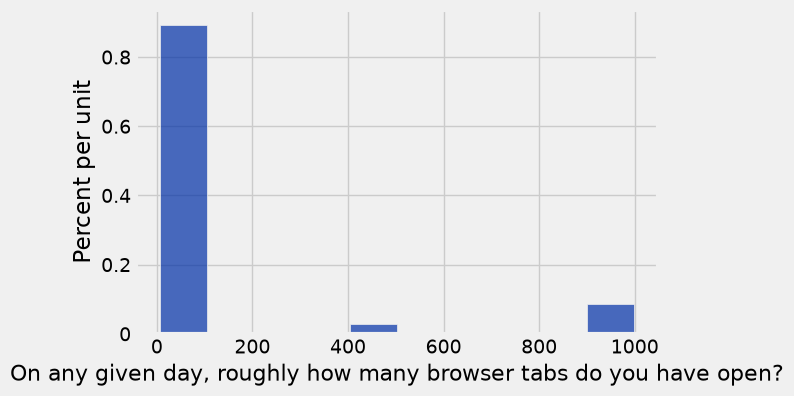

In [44]:
survey.hist(browser_tabs)

In [45]:
tab_bins = make_array(0,10,20,50,100,400,450,500,550,900,1000)

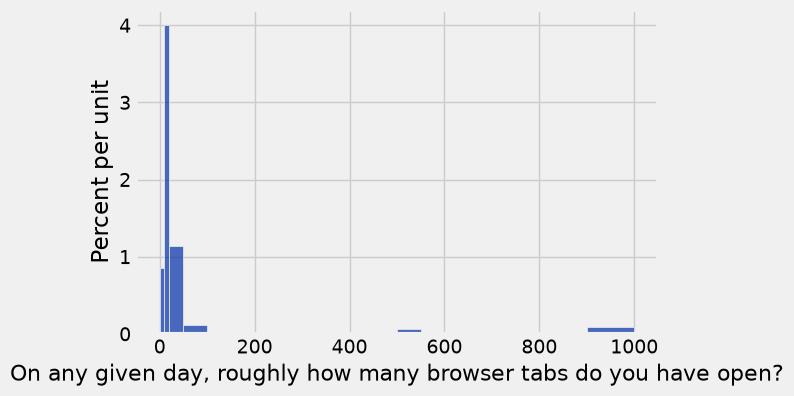

In [46]:
survey.hist(browser_tabs, bins = tab_bins)

In [47]:
survey.bin(browser_tabs, bins = tab_bins)

bin,"On any given day, roughly how many browser tabs do you have open? count"
0,3
10,14
20,12
50,2
100,0
400,0
450,0
500,1
550,0
900,3


## Histograms continued

Last time we loaded how long the highest grossing movies of 2017 had been out (in years) as of 2026.

In [32]:
top_movies = Table.read_table('top_movies_2017.csv')
top_movies.show(6)

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956


We then calculated the ages of each movie and updated our `top_movies` table to include a column with the ages of each movie.

In [33]:
ages = 2026 - top_movies.column('Year')
top_movies = top_movies.with_column('Age', ages)

In [36]:
min(top_movies.column('Age'))

9

In [37]:
max(top_movies.column('Age'))

105

In [34]:
top_movies

Title,Studio,Gross,Gross (Adjusted),Year,Age
Gone with the Wind,MGM,198676459,1796176700,1939,87
Star Wars,Fox,460998007,1583483200,1977,49
The Sound of Music,Fox,158671368,1266072700,1965,61
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982,44
Titanic,Paramount,658672302,1204368000,1997,29
The Ten Commandments,Paramount,65500000,1164590000,1956,70
Jaws,Universal,260000000,1138620700,1975,51
Doctor Zhivago,MGM,111721910,1103564200,1965,61
The Exorcist,Warner Brothers,232906145,983226600,1973,53
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937,89


In [ ]:
top_movies.select('Title', 'Age').show(6)

Running `top_movies.hist('Age')` we were able to produce a histogram with 10 equally sized bins

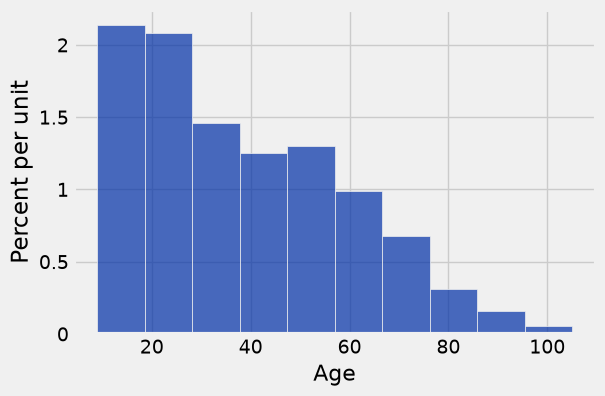

In [35]:
### This is where we stopped last time. 
top_movies.hist('Age')

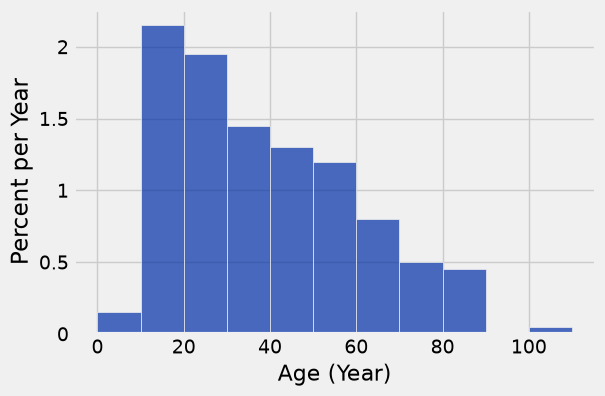

In [38]:
top_movies.hist('Age', bins = np.arange(0, 120, 10), unit = 'Year')

In [39]:
my_bins = make_array(0, 5, 10, 15, 25, 40, 65, 106)

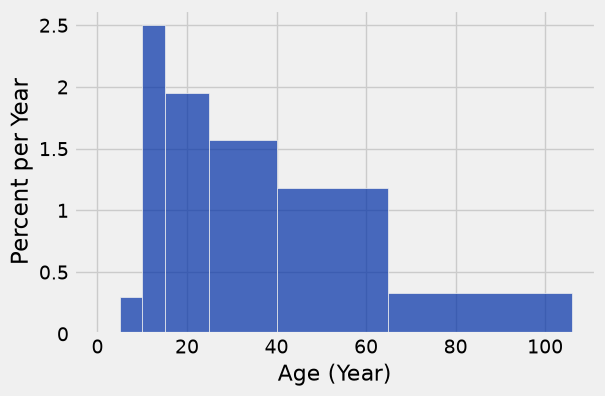

In [40]:
top_movies.hist('Age', bins = my_bins, unit = 'Year')

In [42]:
top_movies.bin('Age', bins=my_bins)

bin,Age count
0,0
5,3
10,25
15,39
25,47
40,59
65,27
106,0


### Functions

In [48]:
# Let's make a function that takes in a value and triples it
x = 3

x * 3

9

In [55]:
def triple(value):
    """Triples an input"""
    tripled_x = value * 3
    return tripled_x

In [57]:
value

NameError: name 'value' is not defined

In [56]:
triple(10)

30

In [58]:
'ha' * 3

'hahaha'

In [59]:
triple('ha')

'hahaha'

In [60]:
triple(np.arange(5))

array([ 0,  3,  6,  9, 12])

### `apply` 

In [ ]:
fam = Table().with_columns(
    'First Name', make_array('Jeremy', 'Olivia', 'Barnard'),
    'Birth Year', make_array(1999, 2005, 2015)
)
fam